Processing samples...


100%|██████████| 10000/10000 [01:35<00:00, 105.01it/s]


All CSI array shape: (10000, 2, 32, 32)
Training STNet autoencoder with encoded_dim=512 ...
epoch 1/100 batch: 1/50 loss_auto: 0.56173986
epoch 1/100 batch: 11/50 loss_auto: 0.43300813
epoch 1/100 batch: 21/50 loss_auto: 0.40419880
epoch 1/100 batch: 31/50 loss_auto: 0.37821218
epoch 1/100 batch: 41/50 loss_auto: 0.36296675
epoch 2/100 batch: 1/50 loss_auto: 0.35278162
epoch 2/100 batch: 11/50 loss_auto: 0.35219359
epoch 2/100 batch: 21/50 loss_auto: 0.34988680
epoch 2/100 batch: 31/50 loss_auto: 0.34048381
epoch 2/100 batch: 41/50 loss_auto: 0.33442226
epoch 3/100 batch: 1/50 loss_auto: 0.33671913
epoch 3/100 batch: 11/50 loss_auto: 0.32746837
epoch 3/100 batch: 21/50 loss_auto: 0.33087528
epoch 3/100 batch: 31/50 loss_auto: 0.32297230
epoch 3/100 batch: 41/50 loss_auto: 0.32074988
epoch 4/100 batch: 1/50 loss_auto: 0.31606361
epoch 4/100 batch: 11/50 loss_auto: 0.32036448
epoch 4/100 batch: 21/50 loss_auto: 0.31270197
epoch 4/100 batch: 31/50 loss_auto: 0.30656046
epoch 4/100 batch: 

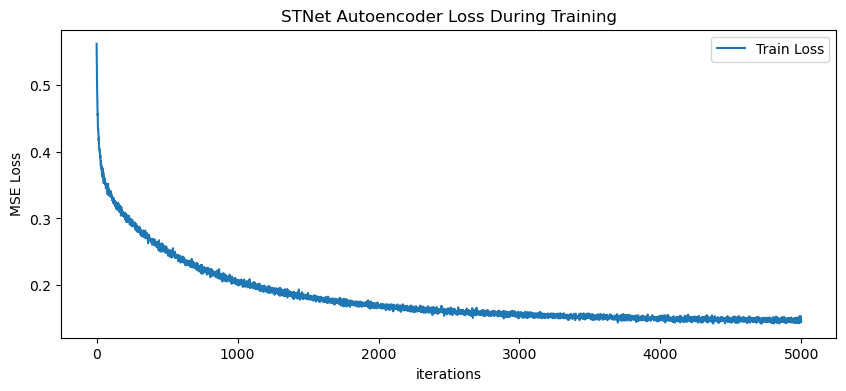

100%|██████████| 50/50 [00:00<00:00, 76.74it/s]


Saved: CSI_Comp_512_30.npy (shape (10000, 512))


In [1]:
import h5py
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
from collections import OrderedDict
import matplotlib.pyplot as plt
from tqdm import tqdm

# ===========================
# CONFIG: Set these for your data
# ===========================
filename = 'H_32x72_30Kmph.mat'  # <-- Change to H_32x72_120Kmph.mat if needed
output_npy = 'CSI_Comp_512_30.npy'  # <-- Change to CSI_Comp_512_120.npy if needed
encoded_dim = 512
epochs = 100
batch_size = 200
learning_rate = 1e-3

# ===========================
# STEP 1: Load and preprocess CSI data (to [N, 2, 32, 32])
# ===========================
with h5py.File(filename, 'r') as f:
    HMat = f['HMat']
    N = HMat.shape[0]
    patches_per_sample = HMat.shape[1]  # usually 16
    n_subcarriers = 72
    n_antennas = 32
    target_sc = 32
    target_ant = 32

    print("Processing samples...")
    all_csi = np.zeros((N, 2, target_sc, target_ant), dtype=np.float32)
    for i in tqdm(range(N)):
        full_real = np.zeros((n_subcarriers, n_antennas * patches_per_sample), dtype=np.float32)
        full_imag = np.zeros((n_subcarriers, n_antennas * patches_per_sample), dtype=np.float32)
        for j in range(patches_per_sample):
            dset = f[HMat[i, j]]
            arr = np.array(dset)
            real = arr['real'][:, 0, :]
            imag = arr['imag'][:, 0, :]
            col_start = j * n_antennas
            col_end = (j + 1) * n_antennas
            full_real[:, col_start:col_end] = real
            full_imag[:, col_start:col_end] = imag
        # Downsample subcarriers (from 72 to 32) by mean-pooling
        pool_factor_sc = n_subcarriers // target_sc
        real_sc = full_real[:target_sc * pool_factor_sc].reshape(target_sc, pool_factor_sc, 512).mean(axis=1)
        imag_sc = full_imag[:target_sc * pool_factor_sc].reshape(target_sc, pool_factor_sc, 512).mean(axis=1)
        # Downsample antennas (from 512 to 32) by mean-pooling
        pool_factor_ant = 512 // target_ant
        real_img = real_sc[:, :target_ant * pool_factor_ant].reshape(target_sc, target_ant, pool_factor_ant).mean(axis=2)
        imag_img = imag_sc[:, :target_ant * pool_factor_ant].reshape(target_sc, target_ant, pool_factor_ant).mean(axis=2)
        all_csi[i, 0] = real_img
        all_csi[i, 1] = imag_img
print("All CSI array shape:", all_csi.shape)

# ===========================
# STEP 2: STNet Autoencoder Modules (as per your design)
# ===========================
img_height = 32
img_width = 32
img_channels = 2
img_total = img_height * img_width * img_channels
num_heads = 4
window = 8
depth = 1
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class GroupAttention(nn.Module):
    def __init__(self, num_heads=4, qkv_bias=False):
        super().__init__()
        self.num_heads = num_heads
        head_dim = img_width // num_heads
        self.scale = head_dim ** -0.5
        self.qkv = nn.Linear(img_width, img_width * 3, bias=qkv_bias)
        self.proj = nn.Linear(img_width, img_width)
        self.ws = window
    def forward(self, x):
        B, C, H, W = x.shape
        h_group, w_group = H // self.ws, W // self.ws
        total_groups = h_group * w_group
        x = x.reshape(B, C, h_group, self.ws, W)
        qkv = self.qkv(x).reshape(B, C, total_groups, -1, 3, self.num_heads, self.ws // self.num_heads).permute(4, 0, 1, 2, 5, 3, 6)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = (attn @ v).transpose(2, 3).reshape(B, h_group, w_group, self.ws, self.ws, C)
        x = attn.transpose(2, 3).reshape(B, C, H, W)
        x = self.proj(x)
        return x

class GlobalAttention(nn.Module):
    def __init__(self, num_heads=4, qkv_bias=False):
        super().__init__()
        self.dim = img_width
        self.num_heads = num_heads
        head_dim = self.dim // num_heads
        self.scale = head_dim ** -0.5
        self.q = nn.Linear(self.dim, self.dim, bias=qkv_bias)
        self.kv = nn.Linear(self.dim//window, self.dim//window * 2, bias=qkv_bias)
        self.proj = nn.Linear(self.dim, self.dim)
        self.sr = nn.Conv2d(2, 2, kernel_size=window, stride=window)
        self.norm = nn.LayerNorm(self.dim//window)
    def forward(self, x):
        B, C, H, W = x.shape
        q = self.q(x).reshape(B, C, -1, self.dim//window, self.dim//window).permute(0,1,3,2,4)
        x_ = self.sr(x).reshape(B, C, -1, self.dim//window, self.dim//window)
        x_ = self.norm(x_)
        kv = self.kv(x_).reshape(B, C, -1, 2, self.dim//window, self.dim//window).permute(3,0,1,4,2,5)
        k, v = kv[0], kv[1]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        x = (attn @ v).transpose(1, 2).reshape(B, C, H, W)
        x = self.proj(x)
        return x

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.cc1 = nn.Linear(img_width, img_width)
        self.cc2 = nn.Linear(img_width, img_width)
        self.act = nn.GELU()
    def forward(self, x):
        x = self.cc1(x)
        x = self.act(x)
        x = self.cc2(x)
        return x

class WTL(nn.Module):
    def __init__(self, num_heads, qkv_bias):
        super().__init__()
        self.norm1 = nn.LayerNorm(img_width, eps=1e-6)
        self.attn1 = GroupAttention(num_heads=num_heads, qkv_bias=qkv_bias)
        self.attn2 = GlobalAttention(num_heads=num_heads, qkv_bias=qkv_bias)
        self.norm2 = nn.LayerNorm(img_width, eps=1e-6)
        self.norm3 = nn.LayerNorm(img_width, eps=1e-6)
        self.norm4 = nn.LayerNorm(img_width, eps=1e-6)
        self.mlp1 = MLP()
        self.mlp2 = MLP()
    def forward(self, x):
        x = x + self.attn1(self.norm1(x))
        x = x + self.mlp1(self.norm2(x))
        x = x + self.attn2(self.norm3(x))
        x = x + self.mlp2(self.norm4(x))
        return x

class ConvBN(nn.Sequential):
    def __init__(self, in_planes, out_planes, kernel_size, stride=1, groups=1):
        if not isinstance(kernel_size, int):
            padding = [(i - 1) // 2 for i in kernel_size]
        else:
            padding = (kernel_size - 1) // 2
        super().__init__(OrderedDict([
            ('conv', nn.Conv2d(in_planes, out_planes, kernel_size, stride, padding=padding, groups=groups, bias=False)),
            ('bn', nn.BatchNorm2d(out_planes))
        ]))

class CRBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.path1 = nn.Sequential(OrderedDict([
            ('conv3x3', ConvBN(2, 7, 3)),
            ('relu1', nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ('conv1x9', ConvBN(7, 7, [1, 9])),
            ('relu2', nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ('conv9x1', ConvBN(7, 7, [9, 1])),
        ]))
        self.path2 = nn.Sequential(OrderedDict([
            ('conv1x5', ConvBN(2, 7, [1, 5])),
            ('relu', nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ('conv5x1', ConvBN(7, 7, [5, 1])),
        ]))
        self.conv1x1 = ConvBN(7 * 2, 2, 1)
        self.identity = nn.Identity()
        self.relu = nn.LeakyReLU(negative_slope=0.3, inplace=True)
    def forward(self, x):
        identity = self.identity(x)
        out1 = self.path1(x)
        out2 = self.path2(x)
        out = torch.cat((out1, out2), dim=1)
        out = self.relu(out)
        out = self.conv1x1(out)
        out = self.relu(out + identity)
        return out

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.blocks = nn.ModuleList([WTL(num_heads=num_heads, qkv_bias=True) for _ in range(depth)])
        self.norm2 = nn.LayerNorm(img_width, eps=1e-6)
        self.norm3 = nn.LayerNorm(img_width, eps=1e-6)
        self.conv1 = nn.Conv2d(2, 16, kernel_size=1, stride=1)
        self.conv5 = nn.Conv2d(16, 2, kernel_size=5, stride=1, padding=2)
        self.conv4 = nn.Conv2d(2, 2, kernel_size=4, stride=2, padding=1)
        self.convT = nn.ConvTranspose2d(2, 2, kernel_size=4, stride=2, padding=1)
        self.fc = nn.Linear(2*img_width*img_height, encoded_dim)
    def forward(self, x):
        n_samples = x.shape[0]
        x = self.conv1(x)
        x = self.conv5(x)
        X = x
        for block in self.blocks:
            x = block(x)
        x = self.norm3(x)
        x = self.convT(x)
        x = X + self.conv4(x)
        x = self.norm2(x)
        x = x.reshape(n_samples, 2*img_height*img_width)
        x = self.fc(x)
        return x

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(encoded_dim, img_channels*img_height*img_width)
        self.act = nn.Sigmoid()
        self.conv5 = nn.Conv2d(2, 2, kernel_size=5, stride=1, padding=2)
        self.conv4 = nn.Conv2d(2, 2, kernel_size=4, stride=2, padding=1)
        self.convT = nn.ConvTranspose2d(2, 2, kernel_size=4, stride=2, padding=1)
        self.blocks = nn.ModuleList([WTL(num_heads=num_heads, qkv_bias=True) for _ in range(depth)])
        self.norm2 = nn.LayerNorm(img_width, eps=1e-6)
        self.norm3 = nn.LayerNorm(img_width, eps=1e-6)
        self.dense_layers = nn.Sequential(nn.Linear(encoded_dim, img_total))
        decoder = OrderedDict([
            ("conv5x5_bn", ConvBN(2, 2, 5)),
            ("relu", nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ("CRBlock1", CRBlock())
        ])
        self.decoder_feature = nn.Sequential(decoder)
    def forward(self, x):
        img = self.dense_layers(x)
        img = img.view(-1, img_channels, img_height, img_width)
        out = self.decoder_feature(img)
        x = self.conv5(img)
        for block in self.blocks:
            x = block((x + out))
        x = self.norm2(x)
        x = self.convT(x)
        x = self.conv4(x)
        for block in self.blocks:
            x = block((x + out))
        x = self.norm3(x)
        x = self.act(x)
        return x

# ===========================
# STEP 3: Prepare data and train autoencoder
# ===========================
x_data = torch.tensor(all_csi, dtype=torch.float32).to(device)
encoder = Encoder().to(device)
decoder = Decoder().to(device)
opt_enc = Adam(encoder.parameters(), learning_rate, betas=(0.5, 0.999))
opt_dec = Adam(decoder.parameters(), learning_rate, betas=(0.5, 0.999))
loss_fn = nn.MSELoss()

def train_autoencoder(uncompressed_images):
    opt_enc.zero_grad()
    opt_dec.zero_grad()
    compressed_data = encoder(uncompressed_images)
    reconstructed_images = decoder(compressed_data)
    loss = loss_fn(uncompressed_images, reconstructed_images)
    loss.backward()
    opt_enc.step()
    opt_dec.step()
    return loss.item()

print("Training STNet autoencoder with encoded_dim=512 ...")
reps = int(len(x_data) / batch_size)
losses_auto = []
for epoch in range(epochs):
    idx = torch.randperm(x_data.size(0))
    for i in range(reps):
        batch = x_data[idx[i*batch_size:(i+1)*batch_size]]
        loss_auto = train_autoencoder(batch)
        if i % 10 == 0:
            print(f'epoch {epoch+1}/{epochs} batch: {i+1}/{reps} loss_auto: {loss_auto:.8f}')
        losses_auto.append(loss_auto)

plt.figure(figsize=(10, 4))
plt.title("STNet Autoencoder Loss During Training")
plt.plot(losses_auto, label="Train Loss")
plt.xlabel("iterations")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

# ===========================
# STEP 4: Compress and save CSI data
# ===========================
encoder.eval()
all_codes = []
with torch.no_grad():
    for i in tqdm(range(0, x_data.shape[0], batch_size)):
        batch = x_data[i:i+batch_size]
        code = encoder(batch)
        all_codes.append(code.cpu().numpy())
    all_codes = np.concatenate(all_codes, axis=0)
np.save(output_npy, all_codes)
print(f"\nSaved: {output_npy} (shape {all_codes.shape})")


In [ ]:
pip install numpy torch tqdm matplotlib h5py


In [3]:
torch.save(decoder.state_dict(), 'stnet_decoder_512.pt')


Processing samples...


100%|██████████| 10000/10000 [01:49<00:00, 91.41it/s]


All CSI array shape: (10000, 2, 32, 32)
Training STNet autoencoder with encoded_dim=512 ...
epoch 1/100 batch: 1/50 loss_auto: 0.55718070
epoch 1/100 batch: 11/50 loss_auto: 0.46811962
epoch 1/100 batch: 21/50 loss_auto: 0.41582358
epoch 1/100 batch: 31/50 loss_auto: 0.39600679
epoch 1/100 batch: 41/50 loss_auto: 0.37533146
epoch 2/100 batch: 1/50 loss_auto: 0.36173701
epoch 2/100 batch: 11/50 loss_auto: 0.36175457
epoch 2/100 batch: 21/50 loss_auto: 0.35346729
epoch 2/100 batch: 31/50 loss_auto: 0.34665337
epoch 2/100 batch: 41/50 loss_auto: 0.34373268
epoch 3/100 batch: 1/50 loss_auto: 0.34172362
epoch 3/100 batch: 11/50 loss_auto: 0.33527690
epoch 3/100 batch: 21/50 loss_auto: 0.33116314
epoch 3/100 batch: 31/50 loss_auto: 0.32648745
epoch 3/100 batch: 41/50 loss_auto: 0.32121050
epoch 4/100 batch: 1/50 loss_auto: 0.32356888
epoch 4/100 batch: 11/50 loss_auto: 0.32209468
epoch 4/100 batch: 21/50 loss_auto: 0.32070160
epoch 4/100 batch: 31/50 loss_auto: 0.31330574
epoch 4/100 batch: 

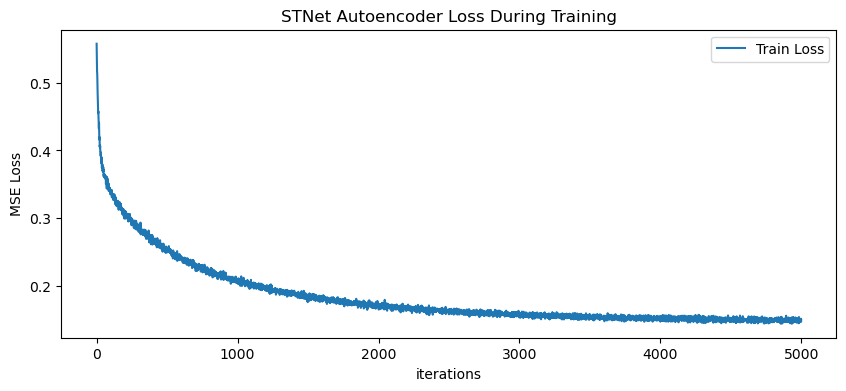

100%|██████████| 50/50 [00:00<00:00, 80.66it/s]



Saved: CSI_Comp_512_120.npy (shape (10000, 512))


In [2]:
import h5py
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
from collections import OrderedDict
import matplotlib.pyplot as plt
from tqdm import tqdm

# ===========================
# CONFIG: Set these for your data
# ===========================
filename = 'H_32x72_120Kmph.mat'  # <-- Change to H_32x72_120Kmph.mat if needed
output_npy = 'CSI_Comp_512_120.npy'  # <-- Change to CSI_Comp_512_120.npy if needed
encoded_dim = 512
epochs = 100
batch_size = 200
learning_rate = 1e-3

# ===========================
# STEP 1: Load and preprocess CSI data (to [N, 2, 32, 32])
# ===========================
with h5py.File(filename, 'r') as f:
    HMat = f['HMat']
    N = HMat.shape[0]
    patches_per_sample = HMat.shape[1]  # usually 16
    n_subcarriers = 72
    n_antennas = 32
    target_sc = 32
    target_ant = 32

    print("Processing samples...")
    all_csi = np.zeros((N, 2, target_sc, target_ant), dtype=np.float32)
    for i in tqdm(range(N)):
        full_real = np.zeros((n_subcarriers, n_antennas * patches_per_sample), dtype=np.float32)
        full_imag = np.zeros((n_subcarriers, n_antennas * patches_per_sample), dtype=np.float32)
        for j in range(patches_per_sample):
            dset = f[HMat[i, j]]
            arr = np.array(dset)
            real = arr['real'][:, 0, :]
            imag = arr['imag'][:, 0, :]
            col_start = j * n_antennas
            col_end = (j + 1) * n_antennas
            full_real[:, col_start:col_end] = real
            full_imag[:, col_start:col_end] = imag
        # Downsample subcarriers (from 72 to 32) by mean-pooling
        pool_factor_sc = n_subcarriers // target_sc
        real_sc = full_real[:target_sc * pool_factor_sc].reshape(target_sc, pool_factor_sc, 512).mean(axis=1)
        imag_sc = full_imag[:target_sc * pool_factor_sc].reshape(target_sc, pool_factor_sc, 512).mean(axis=1)
        # Downsample antennas (from 512 to 32) by mean-pooling
        pool_factor_ant = 512 // target_ant
        real_img = real_sc[:, :target_ant * pool_factor_ant].reshape(target_sc, target_ant, pool_factor_ant).mean(axis=2)
        imag_img = imag_sc[:, :target_ant * pool_factor_ant].reshape(target_sc, target_ant, pool_factor_ant).mean(axis=2)
        all_csi[i, 0] = real_img
        all_csi[i, 1] = imag_img
print("All CSI array shape:", all_csi.shape)

# ===========================
# STEP 2: STNet Autoencoder Modules (as per your design)
# ===========================
img_height = 32
img_width = 32
img_channels = 2
img_total = img_height * img_width * img_channels
num_heads = 4
window = 8
depth = 1
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class GroupAttention(nn.Module):
    def __init__(self, num_heads=4, qkv_bias=False):
        super().__init__()
        self.num_heads = num_heads
        head_dim = img_width // num_heads
        self.scale = head_dim ** -0.5
        self.qkv = nn.Linear(img_width, img_width * 3, bias=qkv_bias)
        self.proj = nn.Linear(img_width, img_width)
        self.ws = window
    def forward(self, x):
        B, C, H, W = x.shape
        h_group, w_group = H // self.ws, W // self.ws
        total_groups = h_group * w_group
        x = x.reshape(B, C, h_group, self.ws, W)
        qkv = self.qkv(x).reshape(B, C, total_groups, -1, 3, self.num_heads, self.ws // self.num_heads).permute(4, 0, 1, 2, 5, 3, 6)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = (attn @ v).transpose(2, 3).reshape(B, h_group, w_group, self.ws, self.ws, C)
        x = attn.transpose(2, 3).reshape(B, C, H, W)
        x = self.proj(x)
        return x

class GlobalAttention(nn.Module):
    def __init__(self, num_heads=4, qkv_bias=False):
        super().__init__()
        self.dim = img_width
        self.num_heads = num_heads
        head_dim = self.dim // num_heads
        self.scale = head_dim ** -0.5
        self.q = nn.Linear(self.dim, self.dim, bias=qkv_bias)
        self.kv = nn.Linear(self.dim//window, self.dim//window * 2, bias=qkv_bias)
        self.proj = nn.Linear(self.dim, self.dim)
        self.sr = nn.Conv2d(2, 2, kernel_size=window, stride=window)
        self.norm = nn.LayerNorm(self.dim//window)
    def forward(self, x):
        B, C, H, W = x.shape
        q = self.q(x).reshape(B, C, -1, self.dim//window, self.dim//window).permute(0,1,3,2,4)
        x_ = self.sr(x).reshape(B, C, -1, self.dim//window, self.dim//window)
        x_ = self.norm(x_)
        kv = self.kv(x_).reshape(B, C, -1, 2, self.dim//window, self.dim//window).permute(3,0,1,4,2,5)
        k, v = kv[0], kv[1]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        x = (attn @ v).transpose(1, 2).reshape(B, C, H, W)
        x = self.proj(x)
        return x

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.cc1 = nn.Linear(img_width, img_width)
        self.cc2 = nn.Linear(img_width, img_width)
        self.act = nn.GELU()
    def forward(self, x):
        x = self.cc1(x)
        x = self.act(x)
        x = self.cc2(x)
        return x

class WTL(nn.Module):
    def __init__(self, num_heads, qkv_bias):
        super().__init__()
        self.norm1 = nn.LayerNorm(img_width, eps=1e-6)
        self.attn1 = GroupAttention(num_heads=num_heads, qkv_bias=qkv_bias)
        self.attn2 = GlobalAttention(num_heads=num_heads, qkv_bias=qkv_bias)
        self.norm2 = nn.LayerNorm(img_width, eps=1e-6)
        self.norm3 = nn.LayerNorm(img_width, eps=1e-6)
        self.norm4 = nn.LayerNorm(img_width, eps=1e-6)
        self.mlp1 = MLP()
        self.mlp2 = MLP()
    def forward(self, x):
        x = x + self.attn1(self.norm1(x))
        x = x + self.mlp1(self.norm2(x))
        x = x + self.attn2(self.norm3(x))
        x = x + self.mlp2(self.norm4(x))
        return x

class ConvBN(nn.Sequential):
    def __init__(self, in_planes, out_planes, kernel_size, stride=1, groups=1):
        if not isinstance(kernel_size, int):
            padding = [(i - 1) // 2 for i in kernel_size]
        else:
            padding = (kernel_size - 1) // 2
        super().__init__(OrderedDict([
            ('conv', nn.Conv2d(in_planes, out_planes, kernel_size, stride, padding=padding, groups=groups, bias=False)),
            ('bn', nn.BatchNorm2d(out_planes))
        ]))

class CRBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.path1 = nn.Sequential(OrderedDict([
            ('conv3x3', ConvBN(2, 7, 3)),
            ('relu1', nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ('conv1x9', ConvBN(7, 7, [1, 9])),
            ('relu2', nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ('conv9x1', ConvBN(7, 7, [9, 1])),
        ]))
        self.path2 = nn.Sequential(OrderedDict([
            ('conv1x5', ConvBN(2, 7, [1, 5])),
            ('relu', nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ('conv5x1', ConvBN(7, 7, [5, 1])),
        ]))
        self.conv1x1 = ConvBN(7 * 2, 2, 1)
        self.identity = nn.Identity()
        self.relu = nn.LeakyReLU(negative_slope=0.3, inplace=True)
    def forward(self, x):
        identity = self.identity(x)
        out1 = self.path1(x)
        out2 = self.path2(x)
        out = torch.cat((out1, out2), dim=1)
        out = self.relu(out)
        out = self.conv1x1(out)
        out = self.relu(out + identity)
        return out

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.blocks = nn.ModuleList([WTL(num_heads=num_heads, qkv_bias=True) for _ in range(depth)])
        self.norm2 = nn.LayerNorm(img_width, eps=1e-6)
        self.norm3 = nn.LayerNorm(img_width, eps=1e-6)
        self.conv1 = nn.Conv2d(2, 16, kernel_size=1, stride=1)
        self.conv5 = nn.Conv2d(16, 2, kernel_size=5, stride=1, padding=2)
        self.conv4 = nn.Conv2d(2, 2, kernel_size=4, stride=2, padding=1)
        self.convT = nn.ConvTranspose2d(2, 2, kernel_size=4, stride=2, padding=1)
        self.fc = nn.Linear(2*img_width*img_height, encoded_dim)
    def forward(self, x):
        n_samples = x.shape[0]
        x = self.conv1(x)
        x = self.conv5(x)
        X = x
        for block in self.blocks:
            x = block(x)
        x = self.norm3(x)
        x = self.convT(x)
        x = X + self.conv4(x)
        x = self.norm2(x)
        x = x.reshape(n_samples, 2*img_height*img_width)
        x = self.fc(x)
        return x

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(encoded_dim, img_channels*img_height*img_width)
        self.act = nn.Sigmoid()
        self.conv5 = nn.Conv2d(2, 2, kernel_size=5, stride=1, padding=2)
        self.conv4 = nn.Conv2d(2, 2, kernel_size=4, stride=2, padding=1)
        self.convT = nn.ConvTranspose2d(2, 2, kernel_size=4, stride=2, padding=1)
        self.blocks = nn.ModuleList([WTL(num_heads=num_heads, qkv_bias=True) for _ in range(depth)])
        self.norm2 = nn.LayerNorm(img_width, eps=1e-6)
        self.norm3 = nn.LayerNorm(img_width, eps=1e-6)
        self.dense_layers = nn.Sequential(nn.Linear(encoded_dim, img_total))
        decoder = OrderedDict([
            ("conv5x5_bn", ConvBN(2, 2, 5)),
            ("relu", nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ("CRBlock1", CRBlock())
        ])
        self.decoder_feature = nn.Sequential(decoder)
    def forward(self, x):
        img = self.dense_layers(x)
        img = img.view(-1, img_channels, img_height, img_width)
        out = self.decoder_feature(img)
        x = self.conv5(img)
        for block in self.blocks:
            x = block((x + out))
        x = self.norm2(x)
        x = self.convT(x)
        x = self.conv4(x)
        for block in self.blocks:
            x = block((x + out))
        x = self.norm3(x)
        x = self.act(x)
        return x

# ===========================
# STEP 3: Prepare data and train autoencoder
# ===========================
x_data = torch.tensor(all_csi, dtype=torch.float32).to(device)
encoder = Encoder().to(device)
decoder = Decoder().to(device)
opt_enc = Adam(encoder.parameters(), learning_rate, betas=(0.5, 0.999))
opt_dec = Adam(decoder.parameters(), learning_rate, betas=(0.5, 0.999))
loss_fn = nn.MSELoss()

def train_autoencoder(uncompressed_images):
    opt_enc.zero_grad()
    opt_dec.zero_grad()
    compressed_data = encoder(uncompressed_images)
    reconstructed_images = decoder(compressed_data)
    loss = loss_fn(uncompressed_images, reconstructed_images)
    loss.backward()
    opt_enc.step()
    opt_dec.step()
    return loss.item()

print("Training STNet autoencoder with encoded_dim=512 ...")
reps = int(len(x_data) / batch_size)
losses_auto = []
for epoch in range(epochs):
    idx = torch.randperm(x_data.size(0))
    for i in range(reps):
        batch = x_data[idx[i*batch_size:(i+1)*batch_size]]
        loss_auto = train_autoencoder(batch)
        if i % 10 == 0:
            print(f'epoch {epoch+1}/{epochs} batch: {i+1}/{reps} loss_auto: {loss_auto:.8f}')
        losses_auto.append(loss_auto)

plt.figure(figsize=(10, 4))
plt.title("STNet Autoencoder Loss During Training")
plt.plot(losses_auto, label="Train Loss")
plt.xlabel("iterations")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

# ===========================
# STEP 4: Compress and save CSI data
# ===========================
encoder.eval()
all_codes = []
with torch.no_grad():
    for i in tqdm(range(0, x_data.shape[0], batch_size)):
        batch = x_data[i:i+batch_size]
        code = encoder(batch)
        all_codes.append(code.cpu().numpy())
    all_codes = np.concatenate(all_codes, axis=0)
np.save(output_npy, all_codes)
print(f"\nSaved: {output_npy} (shape {all_codes.shape})")


Processing samples...


100%|██████████| 10000/10000 [00:16<00:00, 613.49it/s]


All CSI array shape: (10000, 2, 32, 32)
Training STNet autoencoder with encoded_dim=256 ...
epoch 1/100 batch: 1/50 loss_auto: 0.60108763
epoch 1/100 batch: 11/50 loss_auto: 0.49034813
epoch 1/100 batch: 21/50 loss_auto: 0.47046193
epoch 1/100 batch: 31/50 loss_auto: 0.45739454
epoch 1/100 batch: 41/50 loss_auto: 0.46166530
epoch 2/100 batch: 1/50 loss_auto: 0.44199529
epoch 2/100 batch: 11/50 loss_auto: 0.44119880
epoch 2/100 batch: 21/50 loss_auto: 0.43540648
epoch 2/100 batch: 31/50 loss_auto: 0.42597517
epoch 2/100 batch: 41/50 loss_auto: 0.43090808
epoch 3/100 batch: 1/50 loss_auto: 0.41587877
epoch 3/100 batch: 11/50 loss_auto: 0.42154250
epoch 3/100 batch: 21/50 loss_auto: 0.43598312
epoch 3/100 batch: 31/50 loss_auto: 0.43063331
epoch 3/100 batch: 41/50 loss_auto: 0.39662495
epoch 4/100 batch: 1/50 loss_auto: 0.40738875
epoch 4/100 batch: 11/50 loss_auto: 0.41350955
epoch 4/100 batch: 21/50 loss_auto: 0.40754521
epoch 4/100 batch: 31/50 loss_auto: 0.41435111
epoch 4/100 batch: 

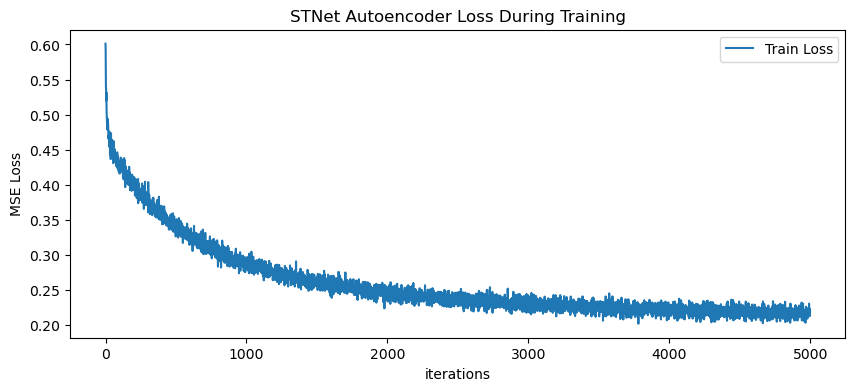

100%|██████████| 50/50 [00:00<00:00, 103.28it/s]


Saved: CSI_Comp_256_paper.npy (shape (10000, 256))


In [10]:
import h5py
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
from collections import OrderedDict
from tqdm import tqdm
import matplotlib.pyplot as plt

# === CONFIG ===
filename = 'H_32x72_120Kmph.mat'
output_npy = 'CSI_Comp_256_paper.npy'
encoded_dim = 256
epochs = 100
batch_size = 200
learning_rate = 1e-3

with h5py.File(filename, 'r') as f:
    HMat = f['HMat']
    N = HMat.shape[0]
    target_sc = 32    # downsample subcarriers
    target_ant = 32   # downsample antennas

    print("Processing samples...")
    all_csi = np.zeros((N, 2, target_sc, target_ant), dtype=np.float32)

    for i in tqdm(range(N)):
        arr = np.array(f[HMat[i, 0]])
        # real/imag shape: (n_sub, n_ant) or (n_sub, 1, n_ant) or (n_sub, n_ant, 1)
        real = arr['real']
        imag = arr['imag']
        
        # Squeeze extra dimensions if present
        real = np.squeeze(real)
        imag = np.squeeze(imag)
        # After squeeze, real shape = (n_sub, n_ant)

        n_subcarriers_actual, n_antenna_actual = real.shape
        # Pad/cut subcarriers to 256
        n_subcarriers = 256
        if n_subcarriers_actual < n_subcarriers:
            real_pad = np.zeros((n_subcarriers, n_antenna_actual), dtype=real.dtype)
            imag_pad = np.zeros((n_subcarriers, n_antenna_actual), dtype=imag.dtype)
            real_pad[:n_subcarriers_actual, :] = real
            imag_pad[:n_subcarriers_actual, :] = imag
            real = real_pad
            imag = imag_pad
        elif n_subcarriers_actual > n_subcarriers:
            real = real[:n_subcarriers, :]
            imag = imag[:n_subcarriers, :]
        # Now real/imag is (256, n_antenna_actual)

        # Downsample subcarriers to 32
        pool_factor_sc = n_subcarriers // target_sc
        real_sc = real[:target_sc * pool_factor_sc].reshape(target_sc, pool_factor_sc, n_antenna_actual).mean(axis=1)
        imag_sc = imag[:target_sc * pool_factor_sc].reshape(target_sc, pool_factor_sc, n_antenna_actual).mean(axis=1)

        # Downsample/pad antennas to 32
        if n_antenna_actual < target_ant:
            real_img = np.zeros((target_sc, target_ant), dtype=np.float32)
            imag_img = np.zeros((target_sc, target_ant), dtype=np.float32)
            real_img[:, :n_antenna_actual] = real_sc
            imag_img[:, :n_antenna_actual] = imag_sc
        elif n_antenna_actual == target_ant:
            real_img = real_sc
            imag_img = imag_sc
        else:
            pool_factor_ant = n_antenna_actual // target_ant
            real_img = real_sc[:, :target_ant * pool_factor_ant].reshape(target_sc, target_ant, pool_factor_ant).mean(axis=2)
            imag_img = imag_sc[:, :target_ant * pool_factor_ant].reshape(target_sc, target_ant, pool_factor_ant).mean(axis=2)
        
        all_csi[i, 0] = real_img
        all_csi[i, 1] = imag_img

print("All CSI array shape:", all_csi.shape)  # [N, 2, 32, 32]

# ---- The rest of your encoder/decoder training code goes below this unchanged ----


# ===========================
# STEP 2: Encoder/Decoder from Paper (from compare.py)
# ===========================
img_size = 32
img_height = 32
img_width = 32
img_channels = 2
img_total = img_height * img_width * img_channels
num_heads = 4
depth = 1
qkv_bias = True
window = 8
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class GroupAttention(nn.Module):
    def __init__(self, num_heads=4, qkv_bias=False):
        super().__init__()
        self.num_heads = num_heads
        head_dim = img_width // num_heads
        self.scale = head_dim ** -0.5
        self.qkv = nn.Linear(img_width, img_width * 3, bias=qkv_bias)
        self.proj = nn.Linear(img_width, img_width)
        self.ws = window
    def forward(self, x):
        B, C, H, W = x.shape
        h_group, w_group = H // self.ws, W // self.ws
        total_groups = h_group * w_group
        x = x.reshape(B, C, h_group, self.ws, W)
        qkv = self.qkv(x).reshape(B, C, total_groups, -1, 3, self.num_heads, self.ws // self.num_heads).permute(4, 0, 1, 2, 5, 3, 6)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = (attn @ v).transpose(2, 3).reshape(B, h_group, w_group, self.ws, self.ws, C)
        x = attn.transpose(2, 3).reshape(B, C, H, W)
        x = self.proj(x)
        return x

class GlobalAttention(nn.Module):
    def __init__(self, num_heads=4, qkv_bias=False):
        super().__init__()
        self.dim = img_width
        self.num_heads = num_heads
        head_dim = self.dim // num_heads
        self.scale = head_dim ** -0.5
        self.q = nn.Linear(self.dim, self.dim, bias=qkv_bias)
        self.kv = nn.Linear(self.dim//window, self.dim//window * 2, bias=qkv_bias)
        self.proj = nn.Linear(self.dim, self.dim)
        self.sr = nn.Conv2d(2, 2, kernel_size=window, stride=window)
        self.norm = nn.LayerNorm(self.dim//window)
    def forward(self, x):
        B, C, H, W = x.shape
        q = self.q(x).reshape(B, C, -1, self.dim//window, self.dim//window).permute(0,1,3,2,4)
        x_ = self.sr(x).reshape(B, C, -1, self.dim//window, self.dim//window)
        x_ = self.norm(x_)
        kv = self.kv(x_).reshape(B, C, -1, 2, self.dim//window, self.dim//window).permute(3,0,1,4,2,5)
        k, v = kv[0], kv[1]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        x = (attn @ v).transpose(1, 2).reshape(B, C, H, W)
        x = self.proj(x)
        return x

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.cc1 = nn.Linear(img_width, img_width)
        self.cc2 = nn.Linear(img_width, img_width)
        self.act = nn.GELU()
    def forward(self, x):
        x = self.cc1(x)
        x = self.act(x)
        x = self.cc2(x)
        return x

class WTL(nn.Module):
    def __init__(self, num_heads, qkv_bias):
        super().__init__()
        self.norm1 = nn.LayerNorm(img_width, eps=1e-6)
        self.attn1 = GroupAttention(num_heads=num_heads, qkv_bias=qkv_bias)
        self.attn2 = GlobalAttention(num_heads=num_heads, qkv_bias=qkv_bias)
        self.norm2 = nn.LayerNorm(img_width, eps=1e-6)
        self.norm3 = nn.LayerNorm(img_width, eps=1e-6)
        self.norm4 = nn.LayerNorm(img_width, eps=1e-6)
        self.mlp1 = MLP()
        self.mlp2 = MLP()
    def forward(self, x):
        x = x + self.attn1(self.norm1(x))
        x = x + self.mlp1(self.norm2(x))
        x = x + self.attn2(self.norm3(x))
        x = x + self.mlp2(self.norm4(x))
        return x

class ConvBN(nn.Sequential):
    def __init__(self, in_planes, out_planes, kernel_size, stride=1, groups=1):
        if not isinstance(kernel_size, int):
            padding = [(i - 1) // 2 for i in kernel_size]
        else:
            padding = (kernel_size - 1) // 2
        super().__init__(OrderedDict([
            ('conv', nn.Conv2d(in_planes, out_planes, kernel_size, stride, padding=padding, groups=groups, bias=False)),
            ('bn', nn.BatchNorm2d(out_planes))
        ]))

class CRBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.path1 = nn.Sequential(OrderedDict([
            ('conv3x3', ConvBN(2, 7, 3)),
            ('relu1', nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ('conv1x9', ConvBN(7, 7, [1, 9])),
            ('relu2', nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ('conv9x1', ConvBN(7, 7, [9, 1])),
        ]))
        self.path2 = nn.Sequential(OrderedDict([
            ('conv1x5', ConvBN(2, 7, [1, 5])),
            ('relu', nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ('conv5x1', ConvBN(7, 7, [5, 1])),
        ]))
        self.conv1x1 = ConvBN(7 * 2, 2, 1)
        self.identity = nn.Identity()
        self.relu = nn.LeakyReLU(negative_slope=0.3, inplace=True)
    def forward(self, x):
        identity = self.identity(x)
        out1 = self.path1(x)
        out2 = self.path2(x)
        out = torch.cat((out1, out2), dim=1)
        out = self.relu(out)
        out = self.conv1x1(out)
        out = self.relu(out + identity)
        return out

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.blocks = nn.ModuleList([WTL(num_heads=num_heads, qkv_bias=True) for _ in range(depth)])
        self.norm2 = nn.LayerNorm(img_width, eps=1e-6)
        self.norm3 = nn.LayerNorm(img_width, eps=1e-6)
        self.conv1 = nn.Conv2d(2, 16, kernel_size=1, stride=1)
        self.conv5 = nn.Conv2d(16, 2, kernel_size=5, stride=1, padding=2)
        self.conv4 = nn.Conv2d(2, 2, kernel_size=4, stride=2, padding=1)
        self.convT = nn.ConvTranspose2d(2, 2, kernel_size=4, stride=2, padding=1)
        self.fc = nn.Linear(2*img_width*img_height, encoded_dim)
    def forward(self, x):
        n_samples = x.shape[0]
        x = self.conv1(x)
        x = self.conv5(x)
        X = x
        for block in self.blocks:
            x = block(x)
        x = self.norm3(x)
        x = self.convT(x)
        x = X + self.conv4(x)
        x = self.norm2(x)
        x = x.reshape(n_samples, 2*img_height*img_width)
        x = self.fc(x)
        return x

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(encoded_dim, img_channels*img_height*img_width)
        self.act = nn.Sigmoid()
        self.conv5 = nn.Conv2d(2, 2, kernel_size=5, stride=1, padding=2)
        self.conv4 = nn.Conv2d(2, 2, kernel_size=4, stride=2, padding=1)
        self.convT = nn.ConvTranspose2d(2, 2, kernel_size=4, stride=2, padding=1)
        self.blocks = nn.ModuleList([WTL(num_heads=num_heads, qkv_bias=True) for _ in range(depth)])
        self.norm2 = nn.LayerNorm(img_width, eps=1e-6)
        self.norm3 = nn.LayerNorm(img_width, eps=1e-6)
        self.dense_layers = nn.Sequential(nn.Linear(encoded_dim, img_total))
        decoder = OrderedDict([
            ("conv5x5_bn", ConvBN(2, 2, 5)),
            ("relu", nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ("CRBlock1", CRBlock())
        ])
        self.decoder_feature = nn.Sequential(decoder)
    def forward(self, x):
        img = self.dense_layers(x)
        img = img.view(-1, img_channels, img_height, img_width)
        out = self.decoder_feature(img)
        x = self.conv5(img)
        for block in self.blocks:
            x = block((x + out))
        x = self.norm2(x)
        x = self.convT(x)
        x = self.conv4(x)
        for block in self.blocks:
            x = block((x + out))
        x = self.norm3(x)
        x = self.act(x)
        return x

# ===========================
# STEP 3: Train STNet Autoencoder
# ===========================
x_data = torch.tensor(all_csi, dtype=torch.float32).to(device)
encoder = Encoder().to(device)
decoder = Decoder().to(device)
opt_enc = Adam(encoder.parameters(), learning_rate, betas=(0.5, 0.999))
opt_dec = Adam(decoder.parameters(), learning_rate, betas=(0.5, 0.999))
loss_fn = nn.MSELoss()

def train_autoencoder(uncompressed_images):
    opt_enc.zero_grad()
    opt_dec.zero_grad()
    compressed_data = encoder(uncompressed_images)
    reconstructed_images = decoder(compressed_data)
    loss = loss_fn(uncompressed_images, reconstructed_images)
    loss.backward()
    opt_enc.step()
    opt_dec.step()
    return loss.item()

print("Training STNet autoencoder with encoded_dim=256 ...")
reps = int(len(x_data) / batch_size)
losses_auto = []
for epoch in range(epochs):
    idx = torch.randperm(x_data.size(0))
    for i in range(reps):
        batch = x_data[idx[i*batch_size:(i+1)*batch_size]]
        loss_auto = train_autoencoder(batch)
        if i % 10 == 0:
            print(f'epoch {epoch+1}/{epochs} batch: {i+1}/{reps} loss_auto: {loss_auto:.8f}')
        losses_auto.append(loss_auto)

plt.figure(figsize=(10, 4))
plt.title("STNet Autoencoder Loss During Training")
plt.plot(losses_auto, label="Train Loss")
plt.xlabel("iterations")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

# ===========================
# STEP 4: Compress and Save CSI Data
# ===========================
encoder.eval()
all_codes = []
with torch.no_grad():
    for i in tqdm(range(0, x_data.shape[0], batch_size)):
        batch = x_data[i:i+batch_size]
        code = encoder(batch)
        all_codes.append(code.cpu().numpy())
    all_codes = np.concatenate(all_codes, axis=0)
np.save(output_npy, all_codes)
print(f"\nSaved: {output_npy} (shape {all_codes.shape})")


In [11]:
torch.save(decoder.state_dict(), 'stnet_paperdecoder_256.pt')